In [ ]:
!pip install -q datasets==2.14.6
!pip install -q transformers==4.40.0 torch scikit-learn accelerate
print(' All libraries installed')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 493.7/493.7 kB 24.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.3/115.3 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.4/166.4 kB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 48.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.4/135.4 kB 8.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
transformers 5.0.0 requires huggingface-hub<2.0,>=1.3.0, but you have huggingface-hub 0.36.2 which is incompatible.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2023.10.0 which is incompatible.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.6/137.6 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 66.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 M

In [ ]:
import re
import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    get_linear_schedule_with_warmup
)

from sklearn.metrics import (
    accuracy_score, f1_score,
    precision_score, recall_score,
    classification_report, confusion_matrix
)
from sklearn.utils.class_weight import compute_class_weight

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f' Device: {device}')
if device.type == 'cuda':
    print(f'   GPU: {torch.cuda.get_device_name(0)}')

 Device: cuda
   GPU: Tesla T4


In [ ]:
import pandas as pd

TRAIN_URL = 'https://raw.githubusercontent.com/PolyAI-LDN/task-specific-datasets/master/banking_data/train.csv'
TEST_URL  = 'https://raw.githubusercontent.com/PolyAI-LDN/task-specific-datasets/master/banking_data/test.csv'

print('Downloading Banking77 dataset from GitHub...')
train_df = pd.read_csv(TRAIN_URL)
test_df  = pd.read_csv(TEST_URL)

print(f'Train shape: {train_df.shape}')
print(f'Test  shape: {test_df.shape}')
print(f'Columns: {train_df.columns.tolist()}')
print(train_df.head(3))

Train shape: (10003, 2)
Test  shape: (3080, 2)
Columns: ['text', 'category']
                                                text      category
0                     I am still waiting on my card?  card_arrival
1  What can I do if my card still hasn't arrived ...  card_arrival
2  I have been waiting over a week. Is the card s...  card_arrival


In [ ]:
label_names = sorted(train_df['category'].unique().tolist())
label2id    = {name: i for i, name in enumerate(label_names)}
id2label    = {i: name for name, i in label2id.items()}
NUM_LABELS  = len(label_names)

train_df['label'] = train_df['category'].map(label2id)
test_df['label']  = test_df['category'].map(label2id)

print(f' Number of intent classes : {NUM_LABELS}')
print(f'Train samples              : {len(train_df)}')
print(f'Test  samples              : {len(test_df)}')
print(f'Sample labels: {label_names[:8]}')

 Number of intent classes : 77
Train samples              : 10003
Test  samples              : 3080
Sample labels: ['Refund_not_showing_up', 'activate_my_card', 'age_limit', 'apple_pay_or_google_pay', 'atm_support', 'automatic_top_up', 'balance_not_updated_after_bank_transfer', 'balance_not_updated_after_cheque_or_cash_deposit']


=== TEXT LENGTH STATS ===
count    10003.0
mean        59.5
std         40.9
min         13.0
25%         36.0
50%         47.0
75%         64.0
max        433.0
Name: text_len, dtype: float64


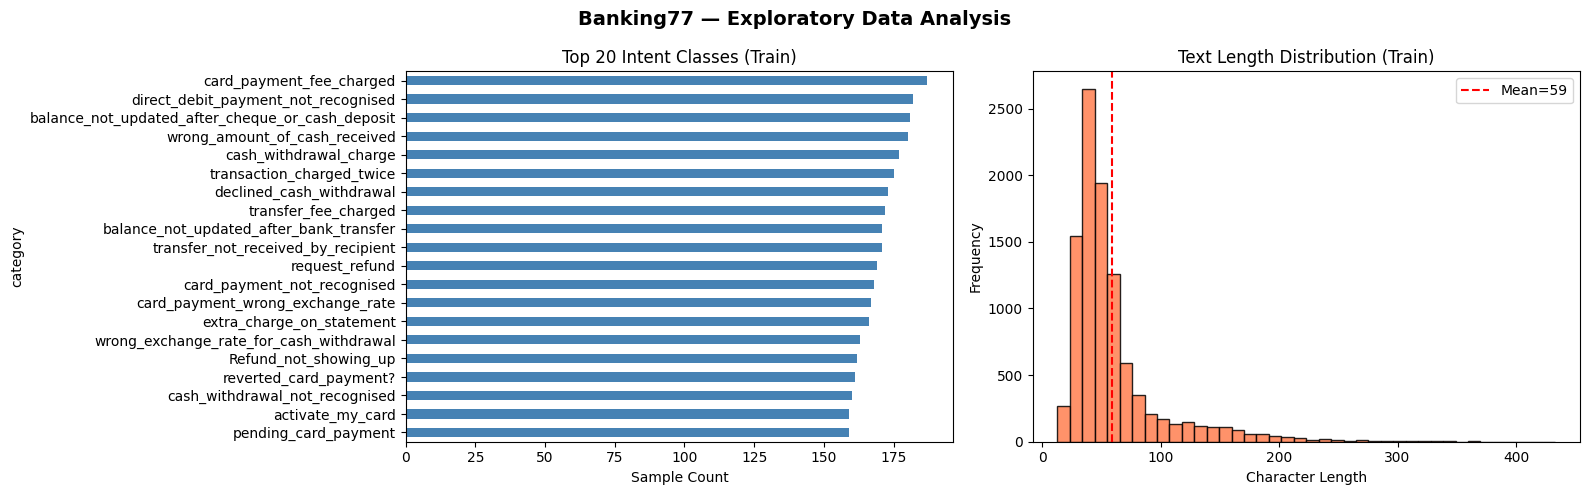

EDA plot saved.


In [ ]:

train_df['text_len'] = train_df['text'].apply(len)

print('=== TEXT LENGTH STATS ===')
print(train_df['text_len'].describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Banking77 — Exploratory Data Analysis', fontsize=14, fontweight='bold')

intent_counts = train_df['category'].value_counts()
intent_counts.head(20).plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 20 Intent Classes (Train)')
axes[0].set_xlabel('Sample Count')
axes[0].invert_yaxis()

axes[1].hist(train_df['text_len'], bins=40, color='coral', edgecolor='black', alpha=0.85)
axes[1].set_title('Text Length Distribution (Train)')
axes[1].set_xlabel('Character Length')
axes[1].set_ylabel('Frequency')
axes[1].axvline(train_df['text_len'].mean(), color='red', linestyle='--', label=f"Mean={train_df['text_len'].mean():.0f}")
axes[1].legend()

plt.tight_layout()
plt.savefig('eda.png', dpi=150, bbox_inches='tight')
plt.show()
print('EDA plot saved.')

In [ ]:
def preprocess_text(text: str) -> str:

    text = str(text).lower()
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'\b\d{8,19}\b', '[ACCOUNT_ID]', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

samples = [
    'My account 4567891234567890 is blocked!',
    '<b>Card Blocked</b> — PLEASE HELP',
    'Where is my transfer?'
]
print('PREPROCESSING DEMO')
print('-' * 55)
for s in samples:
    print(f'  IN : {s}')
    print(f'  OUT: {preprocess_text(s)}')
    print()

train_df['clean_text'] = train_df['text'].apply(preprocess_text)
test_df['clean_text']  = test_df['text'].apply(preprocess_text)
print(' Preprocessing applied to all samples.')

PREPROCESSING DEMO
-------------------------------------------------------
  IN : My account 4567891234567890 is blocked!
  OUT: my account [ACCOUNT_ID] is blocked!

  IN : <b>Card Blocked</b> — PLEASE HELP
  OUT: card blocked — please help

  IN : Where is my transfer?
  OUT: where is my transfer?

 Preprocessing applied to all samples.


In [ ]:
MODEL_NAME = 'distilbert-base-uncased'
MAX_LEN    = 128

tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)
print(f' Tokenizer loaded: {MODEL_NAME}')

sample = 'My card has not arrived yet, what should I do?'
enc = tokenizer(sample, max_length=MAX_LEN, truncation=True, padding='max_length', return_tensors='pt')
print(f'Input shape : {enc["input_ids"].shape}')
print(f'Tokens      : {tokenizer.convert_ids_to_tokens(enc["input_ids"][0])[:12]} ...')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

 Tokenizer loaded: distilbert-base-uncased
Input shape : torch.Size([1, 128])
Tokens      : ['[CLS]', 'my', 'card', 'has', 'not', 'arrived', 'yet', ',', 'what', 'should', 'i', 'do'] ...


In [ ]:
class BankingDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'label':          torch.tensor(self.labels[idx], dtype=torch.long)
        }


BATCH_SIZE = 32

train_dataset = BankingDataset(train_df['clean_text'].tolist(), train_df['label'].tolist(), tokenizer, MAX_LEN)
test_dataset  = BankingDataset(test_df['clean_text'].tolist(),  test_df['label'].tolist(),  tokenizer, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f' Train batches: {len(train_loader)} | Test batches: {len(test_loader)}')

# Verify one batch
batch = next(iter(train_loader))
print(f'Batch input_ids shape : {batch["input_ids"].shape}')
print(f'Batch labels shape    : {batch["label"].shape}')

 Train batches: 313 | Test batches: 97
Batch input_ids shape : torch.Size([32, 128])
Batch labels shape    : torch.Size([32])


In [ ]:
model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=id2label,
    label2id=label2id
)
model = model.to(device)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'   Model loaded: {MODEL_NAME}')
print(f'   Total params    : {total:,}')
print(f'   Trainable params: {trainable:,}')
print(f'   Output classes  : {NUM_LABELS}')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


   Model loaded: distilbert-base-uncased
   Total params    : 67,012,685
   Trainable params: 67,012,685
   Output classes  : 77


In [ ]:
EPOCHS       = 5
LR           = 2e-5
WARMUP_RATIO = 0.1

total_steps  = len(train_loader) * EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

loss_fn = nn.CrossEntropyLoss(weight=class_weights_tensor)

print(f'Epochs        : {EPOCHS}')
print(f'Learning rate : {LR}')
print(f'Total steps   : {total_steps}')
print(f'Warmup steps  : {warmup_steps}')
print(f'Loss          : Weighted CrossEntropyLoss')

Epochs        : 5
Learning rate : 2e-05
Total steps   : 1565
Warmup steps  : 156
Loss          : Weighted CrossEntropyLoss


In [ ]:
def train_one_epoch(model, loader, optimizer, scheduler, loss_fn, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for step, batch in enumerate(loader):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        loss    = loss_fn(outputs.logits, labels)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # Gradient clipping
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        preds       = outputs.logits.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)

        if (step + 1) % 50 == 0:
            print(f'    Step {step+1}/{len(loader)} | Loss: {loss.item():.4f}')

    return total_loss / len(loader), correct / total


def evaluate(model, loader, loss_fn, device):
    model.eval()
    total_loss  = 0.0
    all_preds   = []
    all_labels  = []

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['label'].to(device)

            outputs    = model(input_ids=input_ids, attention_mask=attention_mask)
            loss       = loss_fn(outputs.logits, labels)
            total_loss += loss.item()

            preds = outputs.logits.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc        = accuracy_score(all_labels, all_preds)
    macro_f1   = f1_score(all_labels, all_preds, average='macro',    zero_division=0)
    weighted_f1= f1_score(all_labels, all_preds, average='weighted', zero_division=0)

    return total_loss / len(loader), acc, macro_f1, weighted_f1, all_preds, all_labels

print(' Training and evaluation functions defined.')

 Training and evaluation functions defined.


In [ ]:
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss':   [], 'val_acc':   [], 'val_macro_f1': []
}
best_macro_f1   = 0.0
BEST_MODEL_PATH = 'best_model.pt'

print('🚀 Starting Training...')
print('=' * 60)

for epoch in range(1, EPOCHS + 1):
    print(f'\nEPOCH {epoch}/{EPOCHS}')
    print('-' * 40)

    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, scheduler, loss_fn, device)
    vl_loss, vl_acc, vl_f1, vl_wf1, _, _ = evaluate(model, test_loader, loss_fn, device)

    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(vl_loss)
    history['val_acc'].append(vl_acc)
    history['val_macro_f1'].append(vl_f1)

    print(f'  Train  — Loss: {tr_loss:.4f}  Acc: {tr_acc*100:.2f}%')
    print(f'  Val    — Loss: {vl_loss:.4f}  Acc: {vl_acc*100:.2f}%  MacroF1: {vl_f1:.4f}  WeightedF1: {vl_wf1:.4f}')

    if vl_f1 > best_macro_f1:
        best_macro_f1 = vl_f1
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print(f'  💾 Best model saved (MacroF1={best_macro_f1:.4f})')

print('\n Training complete!')
print(f'Best Macro F1 achieved: {best_macro_f1:.4f}')

🚀 Starting Training...

EPOCH 1/5
----------------------------------------
    Step 50/313 | Loss: 4.3057
    Step 100/313 | Loss: 4.2899
    Step 150/313 | Loss: 3.9899
    Step 200/313 | Loss: 3.6186
    Step 250/313 | Loss: 3.4072
    Step 300/313 | Loss: 3.0323
  Train  — Loss: 3.8392  Acc: 27.64%
  Val    — Loss: 2.7495  Acc: 62.53%  MacroF1: 0.5905  WeightedF1: 0.5905
  💾 Best model saved (MacroF1=0.5905)

EPOCH 2/5
----------------------------------------
    Step 50/313 | Loss: 2.5330
    Step 100/313 | Loss: 2.4186
    Step 150/313 | Loss: 2.0124
    Step 200/313 | Loss: 2.2334
    Step 250/313 | Loss: 1.7545
    Step 300/313 | Loss: 1.5513
  Train  — Loss: 2.1321  Acc: 72.12%
  Val    — Loss: 1.4076  Acc: 81.01%  MacroF1: 0.8003  WeightedF1: 0.8003
  💾 Best model saved (MacroF1=0.8003)

EPOCH 3/5
----------------------------------------
    Step 50/313 | Loss: 1.2929
    Step 100/313 | Loss: 1.3238
    Step 150/313 | Loss: 1.4590
    Step 200/313 | Loss: 1.2795
    Step 250/3

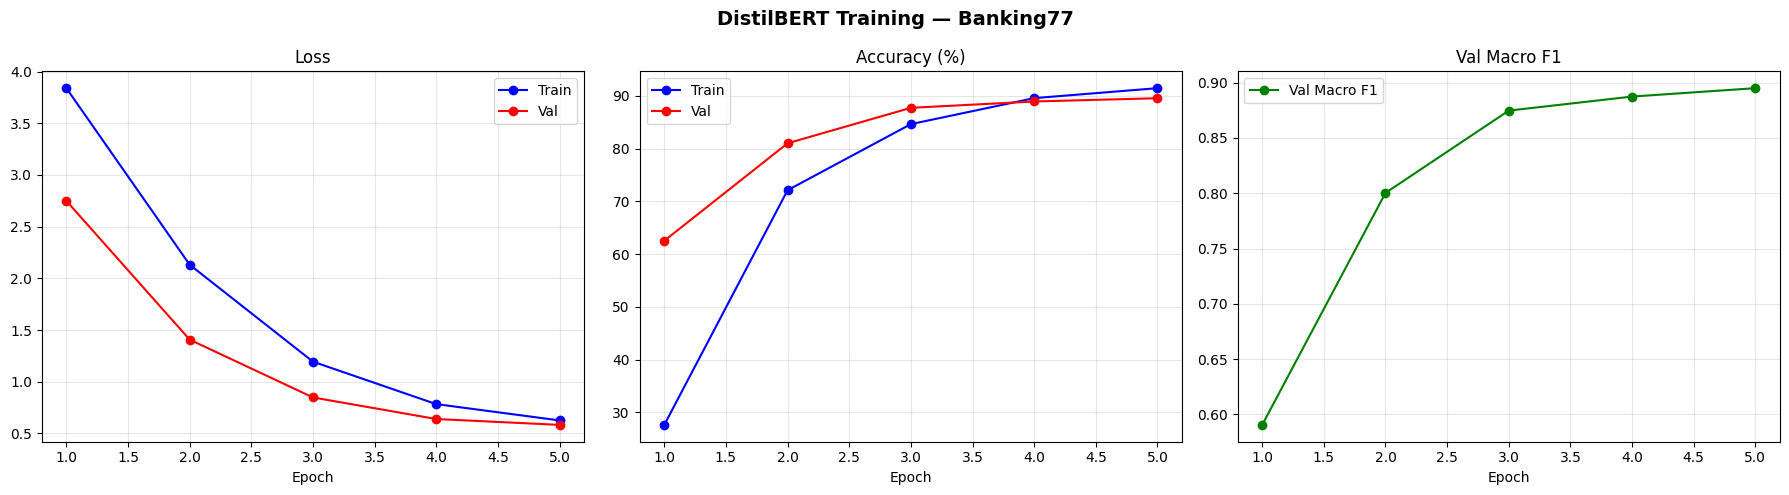

Training curves saved.


In [ ]:
epochs_x = range(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('DistilBERT Training — Banking77', fontsize=14, fontweight='bold')

axes[0].plot(epochs_x, history['train_loss'], 'b-o', label='Train')
axes[0].plot(epochs_x, history['val_loss'],   'r-o', label='Val')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_x, [a*100 for a in history['train_acc']], 'b-o', label='Train')
axes[1].plot(epochs_x, [a*100 for a in history['val_acc']],   'r-o', label='Val')
axes[1].set_title('Accuracy (%)')
axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(epochs_x, history['val_macro_f1'], 'g-o', label='Val Macro F1')
axes[2].set_title('Val Macro F1')
axes[2].set_xlabel('Epoch'); axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Training curves saved.')

In [ ]:
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
model.eval()

_, test_acc, test_macro_f1, test_wf1, y_pred, y_true = evaluate(model, test_loader, loss_fn, device)

precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
recall    = recall_score(y_true, y_pred, average='macro', zero_division=0)

print('=' * 55)
print('        FINAL TEST SET RESULTS')
print('=' * 55)
print(f'  Accuracy          : {test_acc*100:.2f}%')
print(f'  Macro Precision   : {precision:.4f}')
print(f'  Macro Recall      : {recall:.4f}')
print(f'  Macro F1-Score    : {test_macro_f1:.4f}')
print(f'  Weighted F1-Score : {test_wf1:.4f}')
print('=' * 55)

        FINAL TEST SET RESULTS
  Accuracy          : 89.55%
  Macro Precision   : 0.9024
  Macro Recall      : 0.8955
  Macro F1-Score    : 0.8950
  Weighted F1-Score : 0.8950


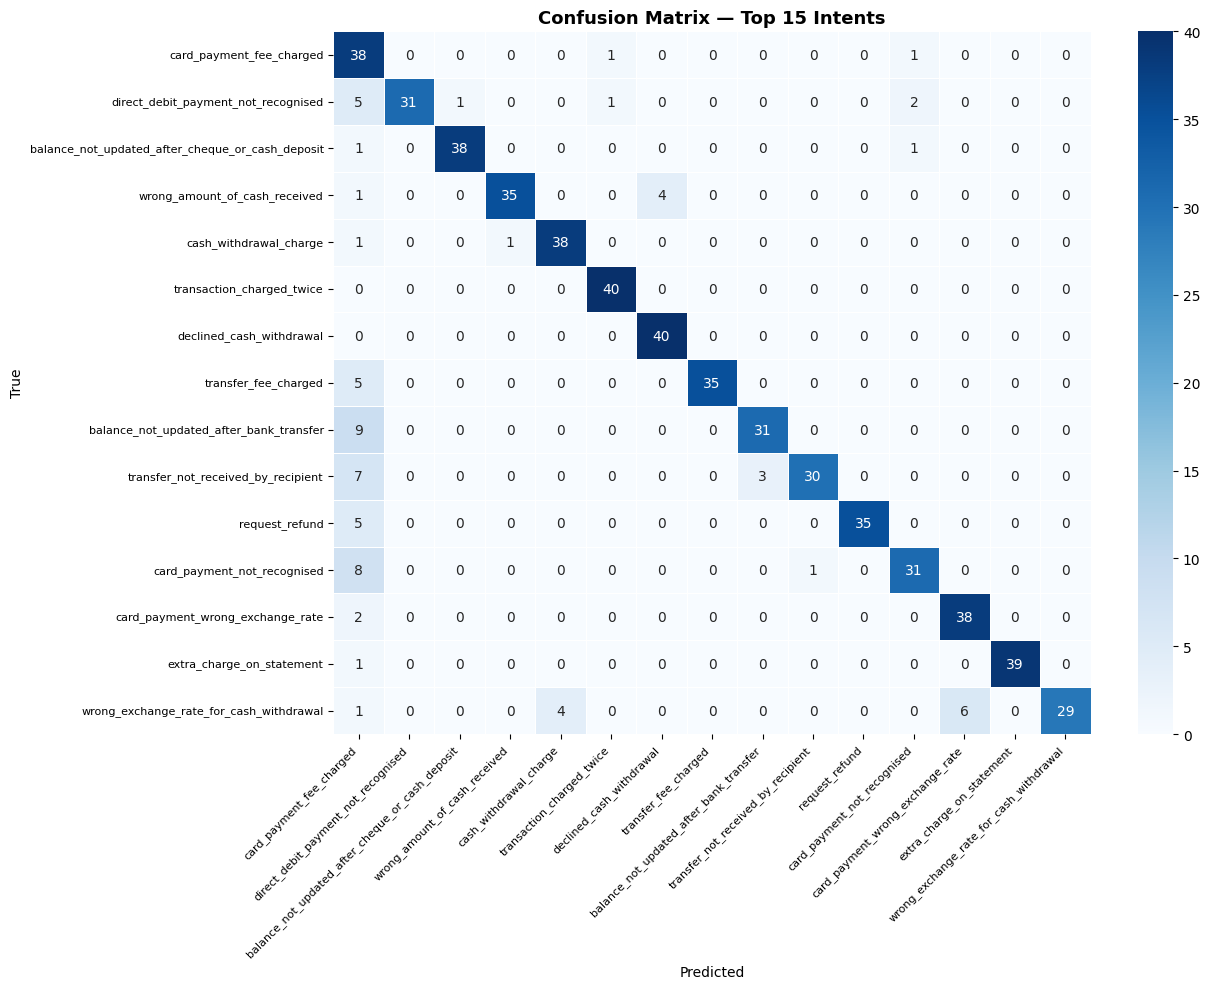

Confusion matrix saved.


In [ ]:
top15_ids   = list(train_df['label'].value_counts().head(15).index)
top15_names = [id2label[i] for i in top15_ids]

mask       = [i for i, yt in enumerate(y_true) if yt in top15_ids]
yt_filtered = [top15_ids.index(y_true[i]) for i in mask]
yp_filtered = [top15_ids.index(y_pred[i]) if y_pred[i] in top15_ids else 0 for i in mask]

cm = confusion_matrix(yt_filtered, yp_filtered)

plt.figure(figsize=(13, 10))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=top15_names, yticklabels=top15_names,
    linewidths=0.4
)
plt.title('Confusion Matrix — Top 15 Intents', fontsize=13, fontweight='bold')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Confusion matrix saved.')

In [ ]:
report = classification_report(
    y_true, y_pred,
    target_names=[id2label[i] for i in range(NUM_LABELS)],
    zero_division=0,
    output_dict=True
)

report_df = pd.DataFrame(report).T.iloc[:-3]  # Drop avg rows
report_df = report_df[['precision','recall','f1-score','support']].round(3)
report_df = report_df.sort_values('f1-score', ascending=False)

print('TOP 15 INTENTS BY F1-SCORE:')
print(report_df.head(15).to_string())
print('\nBOTTOM 10 INTENTS (needs improvement):')
print(report_df.tail(10).to_string())

TOP 15 INTENTS BY F1-SCORE:
                                                  precision  recall  f1-score  support
atm_support                                           1.000   1.000     1.000     40.0
apple_pay_or_google_pay                               1.000   1.000     1.000     40.0
passcode_forgotten                                    1.000   1.000     1.000     40.0
verify_source_of_funds                                1.000   1.000     1.000     40.0
verify_top_up                                         1.000   1.000     1.000     40.0
edit_personal_details                                 0.976   1.000     0.988     40.0
age_limit                                             1.000   0.975     0.987     40.0
extra_charge_on_statement                             1.000   0.975     0.987     40.0
card_about_to_expire                                  0.952   1.000     0.976     40.0
lost_or_stolen_phone                                  0.975   0.975     0.975     40.0
country_support

In [ ]:
def get_department(intent: str) -> str:
    intent = intent.lower()
    if any(k in intent for k in ['fraud', 'scam', 'compromised', 'unauthorised', 'phishing']):
        return ' FRAUD TEAM'
    elif any(k in intent for k in ['card', 'pin']):
        return 'Card Services'
    elif any(k in intent for k in ['transfer', 'payment', 'top_up', 'topping']):
        return 'Transfers & Payments'
    elif any(k in intent for k in ['balance', 'account']):
        return 'Account Services'
    elif any(k in intent for k in ['exchange', 'cash', 'atm', 'currency']):
        return 'Currency & ATM'
    elif any(k in intent for k in ['loan', 'mortgage', 'credit']):
        return 'Loans & Credit'
    else:
        return 'General Support'


def predict(text: str, top_k: int = 3) -> dict:
    """Classify a customer email and route to the correct department."""
    model.eval()
    clean = preprocess_text(text)
    enc   = tokenizer(
        clean, max_length=MAX_LEN,
        padding='max_length', truncation=True, return_tensors='pt'
    )
    with torch.no_grad():
        logits = model(
            input_ids=enc['input_ids'].to(device),
            attention_mask=enc['attention_mask'].to(device)
        ).logits
        probs = torch.softmax(logits, dim=1).squeeze()

    top_probs, top_idx = torch.topk(probs, top_k)
    top_results = [
        {'intent': id2label[i.item()], 'confidence': p.item()}
        for i, p in zip(top_idx, top_probs)
    ]
    best_intent = top_results[0]['intent']
    return {
        'text':       text,
        'intent':     best_intent,
        'confidence': top_results[0]['confidence'],
        'top_k':      top_results,
        'department': get_department(best_intent)
    }


def show(result):
    print('-' * 65)
    print(f"Email      : {result['text']}")
    print(f" Intent     : {result['intent']}")
    print(f"Confidence : {result['confidence']*100:.1f}%")
    print(f"Route to   : {result['department']}")
    print('   Top-3 predictions:')
    for i, r in enumerate(result['top_k'], 1):
        print(f"     {i}. {r['intent']:<45} {r['confidence']*100:.1f}%")


demo_emails = [
    'My card has not arrived yet, it has been 2 weeks!',
    'I see a charge on my account that I did not make.',
    'What is my current balance?',
    'I sent money to my friend but they never received it.',
    'I lost my card while travelling abroad.',
    'Why was I charged an extra fee for my transfer?',
    'My PIN is not working at the ATM.',
    'I cannot top up my account using bank transfer.',
    'Someone is using my card without my permission!',
    'How do I change my account currency?'
]

print('\n BANKING EMAIL INTENT CLASSIFICATION DEMO')
print('=' * 65)
for email in demo_emails:
    show(predict(email))
print('-' * 65)


 BANKING EMAIL INTENT CLASSIFICATION DEMO
-----------------------------------------------------------------
Email      : My card has not arrived yet, it has been 2 weeks!
 Intent     : card_arrival
Confidence : 48.9%
Route to   : Card Services
   Top-3 predictions:
     1. card_arrival                                  48.9%
     2. card_delivery_estimate                        27.0%
     3. card_linking                                  1.7%
-----------------------------------------------------------------
Email      : I see a charge on my account that I did not make.
 Intent     : card_payment_not_recognised
Confidence : 58.2%
Route to   : Card Services
   Top-3 predictions:
     1. card_payment_not_recognised                   58.2%
     2. direct_debit_payment_not_recognised           9.8%
     3. transaction_charged_twice                     3.1%
-----------------------------------------------------------------
Email      : What is my current balance?
 Intent     : balance_not_upda

In [ ]:
SAVE_DIR = './banking77_distilbert'
os.makedirs(SAVE_DIR, exist_ok=True)

model.save_pretrained(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)

with open(f'{SAVE_DIR}/label_names.json', 'w') as f:
    json.dump(label_names, f)

print(f' Model saved to: {SAVE_DIR}')
for fname in os.listdir(SAVE_DIR):
    size_mb = os.path.getsize(f'{SAVE_DIR}/{fname}') / 1e6
    print(f'   {fname:<40} {size_mb:.1f} MB')

 Model saved to: ./banking77_distilbert
   special_tokens_map.json                  0.0 MB
   model.safetensors                        268.1 MB
   tokenizer.json                           0.7 MB
   config.json                              0.0 MB
   label_names.json                         0.0 MB
   tokenizer_config.json                    0.0 MB
   vocab.txt                                0.2 MB


In [ ]:
print()
print('=' * 60)
print('           PROJECT RESULTS SUMMARY')
print('=' * 60)
print(f'  Model          : DistilBERT (distilbert-base-uncased)')
print(f'  Dataset        : Banking77 (PolyAI — GitHub CSV)')
print(f'  Intent Classes : {NUM_LABELS}')
print(f'  Train Samples  : {len(train_df)}')
print(f'  Test  Samples  : {len(test_df)}')
print(f'  Epochs         : {EPOCHS}')
print('-' * 60)
print(f'  Test Accuracy        : {test_acc*100:.2f}%')
print(f'  Macro Precision      : {precision:.4f}')
print(f'  Macro Recall         : {recall:.4f}')
print(f'  Macro F1-Score       : {test_macro_f1:.4f}')
print(f'  Weighted F1-Score    : {test_wf1:.4f}')
print('=' * 60)
print()
print('  Features:')
print('     Robust CSV dataset loading ( HuggingFace script)')
print('     PII masking (account/card numbers)')
print('     Weighted CrossEntropyLoss (class imbalance)')
print('     Gradient clipping (norm=1.0)')
print('     Linear warmup + decay LR schedule')
print('     Best model checkpoint (by Macro F1)')
print('     Auto department routing')
print('     Top-K confidence predictions')
print('=' * 60)


           PROJECT RESULTS SUMMARY
  Model          : DistilBERT (distilbert-base-uncased)
  Dataset        : Banking77 (PolyAI — GitHub CSV)
  Intent Classes : 77
  Train Samples  : 10003
  Test  Samples  : 3080
  Epochs         : 5
------------------------------------------------------------
  Test Accuracy        : 89.55%
  Macro Precision      : 0.9024
  Macro Recall         : 0.8955
  Macro F1-Score       : 0.8950
  Weighted F1-Score    : 0.8950

  Features:
     Robust CSV dataset loading ( HuggingFace script)
     PII masking (account/card numbers)
     Weighted CrossEntropyLoss (class imbalance)
     Gradient clipping (norm=1.0)
     Linear warmup + decay LR schedule
     Best model checkpoint (by Macro F1)
     Auto department routing
     Top-K confidence predictions
